# Analisis de mercado y atraccion de estaciones del subte de CABA

Este notebook implementa los ejercicios 2 y 3 del trabajo practico reutilizando la red base ya construida en `analisis_conectividad_subte_caba.py`. El ejercicio 1 queda documentado en `analisis_conectividad_subte_caba.ipynb`, que construye, valida y caracteriza la red.

La idea es mantener el mismo flujo que el notebook anterior: una sola llamada genera tablas y figuras, y despues cada seccion muestra los resultados mas utiles para discutir el mercado potencial, la atraccion urbana y los cambios en los flujos OD.

La lectura recomendada es:

1. chequear primero el empalme entre red, molinetes y fuentes externas,
2. interpretar el ejercicio 2 como mercado residencial potencial y no como demanda observada,
3. usar el ejercicio 3 para ver que cambia cuando el destino incorpora atraccion urbana cercana.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from analisis_mercado_atraccion_subte_caba import generate_outputs

BASE_DIR = Path.cwd()
FIGURES_DIR = BASE_DIR / 'figures'

DEMAND_RADIUS_M = 800
POI_RADIUS_M = 400
D0_MINUTES = 15.0

results = generate_outputs(
    demand_radius_m=DEMAND_RADIUS_M,
    poi_radius_m=POI_RADIUS_M,
    decay_minutes=D0_MINUTES,
)

config = results['config']
diagnostics = results['diagnostics']
mapping_diagnostics = results['mapping_diagnostics']
correlations = results['correlations']
model_summary = results['model_summary']
top_demand = results['top_demand']
top_attraction = results['top_attraction']
top_betweenness_demand = results['top_betweenness_demand']
top_betweenness_attraction = results['top_betweenness_attraction']
station_metrics = results['station_metrics']

## 1. Supuestos y chequeos

Antes de mirar los resultados conviene dejar explicitadas cuatro decisiones metodologicas:

- la demanda potencial se mide con radios censales a menos de `800 m` de cada estacion,
- la atraccion se mide con puntos de interes descargados de OpenStreetMap via Overpass API a menos de `400 m`,
- la comparacion con molinetes usa los archivos de validaciones cada 15 minutos provistos en `data/molinetes-2024/`,
- `pasajeros_diarios_promedio` se interpreta como promedio por dia observado, no como promedio anual corrido, porque la cobertura temporal no es identica en todas las estaciones.

El cambio de dataset mejora el empalme entre fuentes: en 2024 la linea A si trae registros para `Plaza de Mayo`, asi que ese faltante desaparece. Ademas, al incorporar `Echeverria` en la linea B dentro de la red base, el empalme entre estaciones de la red y estaciones observadas en molinetes queda completo despues de normalizar nombres.

Tambien conviene dejar asentado un caveat de definicion: los archivos de diciembre vienen nombrados como `INCLUYEOTROMODOSDEPAGO`. Para este trabajo se incorporan porque son parte del paquete 2024 recibido y mejoran la cobertura anual, pero eso implica que diciembre no es estrictamente identico al resto del ano en la definicion operativa de validacion.

In [2]:
config

,parametro,valor
0,radio_demanda_m,800
1,radio_poi_m,400
2,d0_minutos,15.0
3,molinetes_periodo,2024-01-01 a 2024-12-31
4,molinetes_fuente,data/molinetes-2024 (24 archivos)


In [3]:
diagnostics

,indicador,valor
0,estaciones_red,90
1,estaciones_con_molinetes_matcheadas,90
2,estaciones_red_sin_molinetes,0
3,estaciones_molinetes_sin_red,0
4,dias_molinetes_observados,364
5,fechas_molinetes_faltantes_en_periodo,2
6,estaciones_con_cobertura_total,67
7,estaciones_con_cobertura_parcial,23
8,radios_censales,3554
9,poi_educacion_descargados,3039


In [4]:
display(mapping_diagnostics['turnstiles_without_network_station'])
display(mapping_diagnostics['stations_without_turnstiles'])

,linea,estacion_molinetes


,linea,estacion_red


En sintesis, el empalme entre fuentes queda completo: las 90 estaciones de la red tienen molinetes comparables con el dataset 2024. `Plaza de Mayo` deja de ser un faltante y `Echeverria` ya no aparece como sobrante porque ahora forma parte de la red base. Al mismo tiempo, la tabla de diagnostico deja ver un caveat importante: el ano cubre 364 fechas de red y la cantidad de dias observados varia entre estaciones, sobre todo en algunas estaciones de las lineas D y B; por eso la comparacion con molinetes conviene leerla como intensidad media en dias observados y no como volumen anual completo.

## 2. Ejercicio 2: mercado potencial de cada estacion

El mapa siguiente resume la demanda potencial `D_i` de cada estacion a partir de la poblacion censal cercana. El tamano y el color de cada nodo crecen cuando la estacion captura mas poblacion residente dentro del radio elegido.

Es importante marcar la interpretacion correcta: este indicador aproxima mercado residencial cercano, no afluencia real de pasajeros. Por eso sirve para responder donde hay mas poblacion accesible a pie alrededor de una estacion, pero no alcanza por si solo para explicar transbordos, centralidades laborales o viajes atraidos por actividades urbanas.

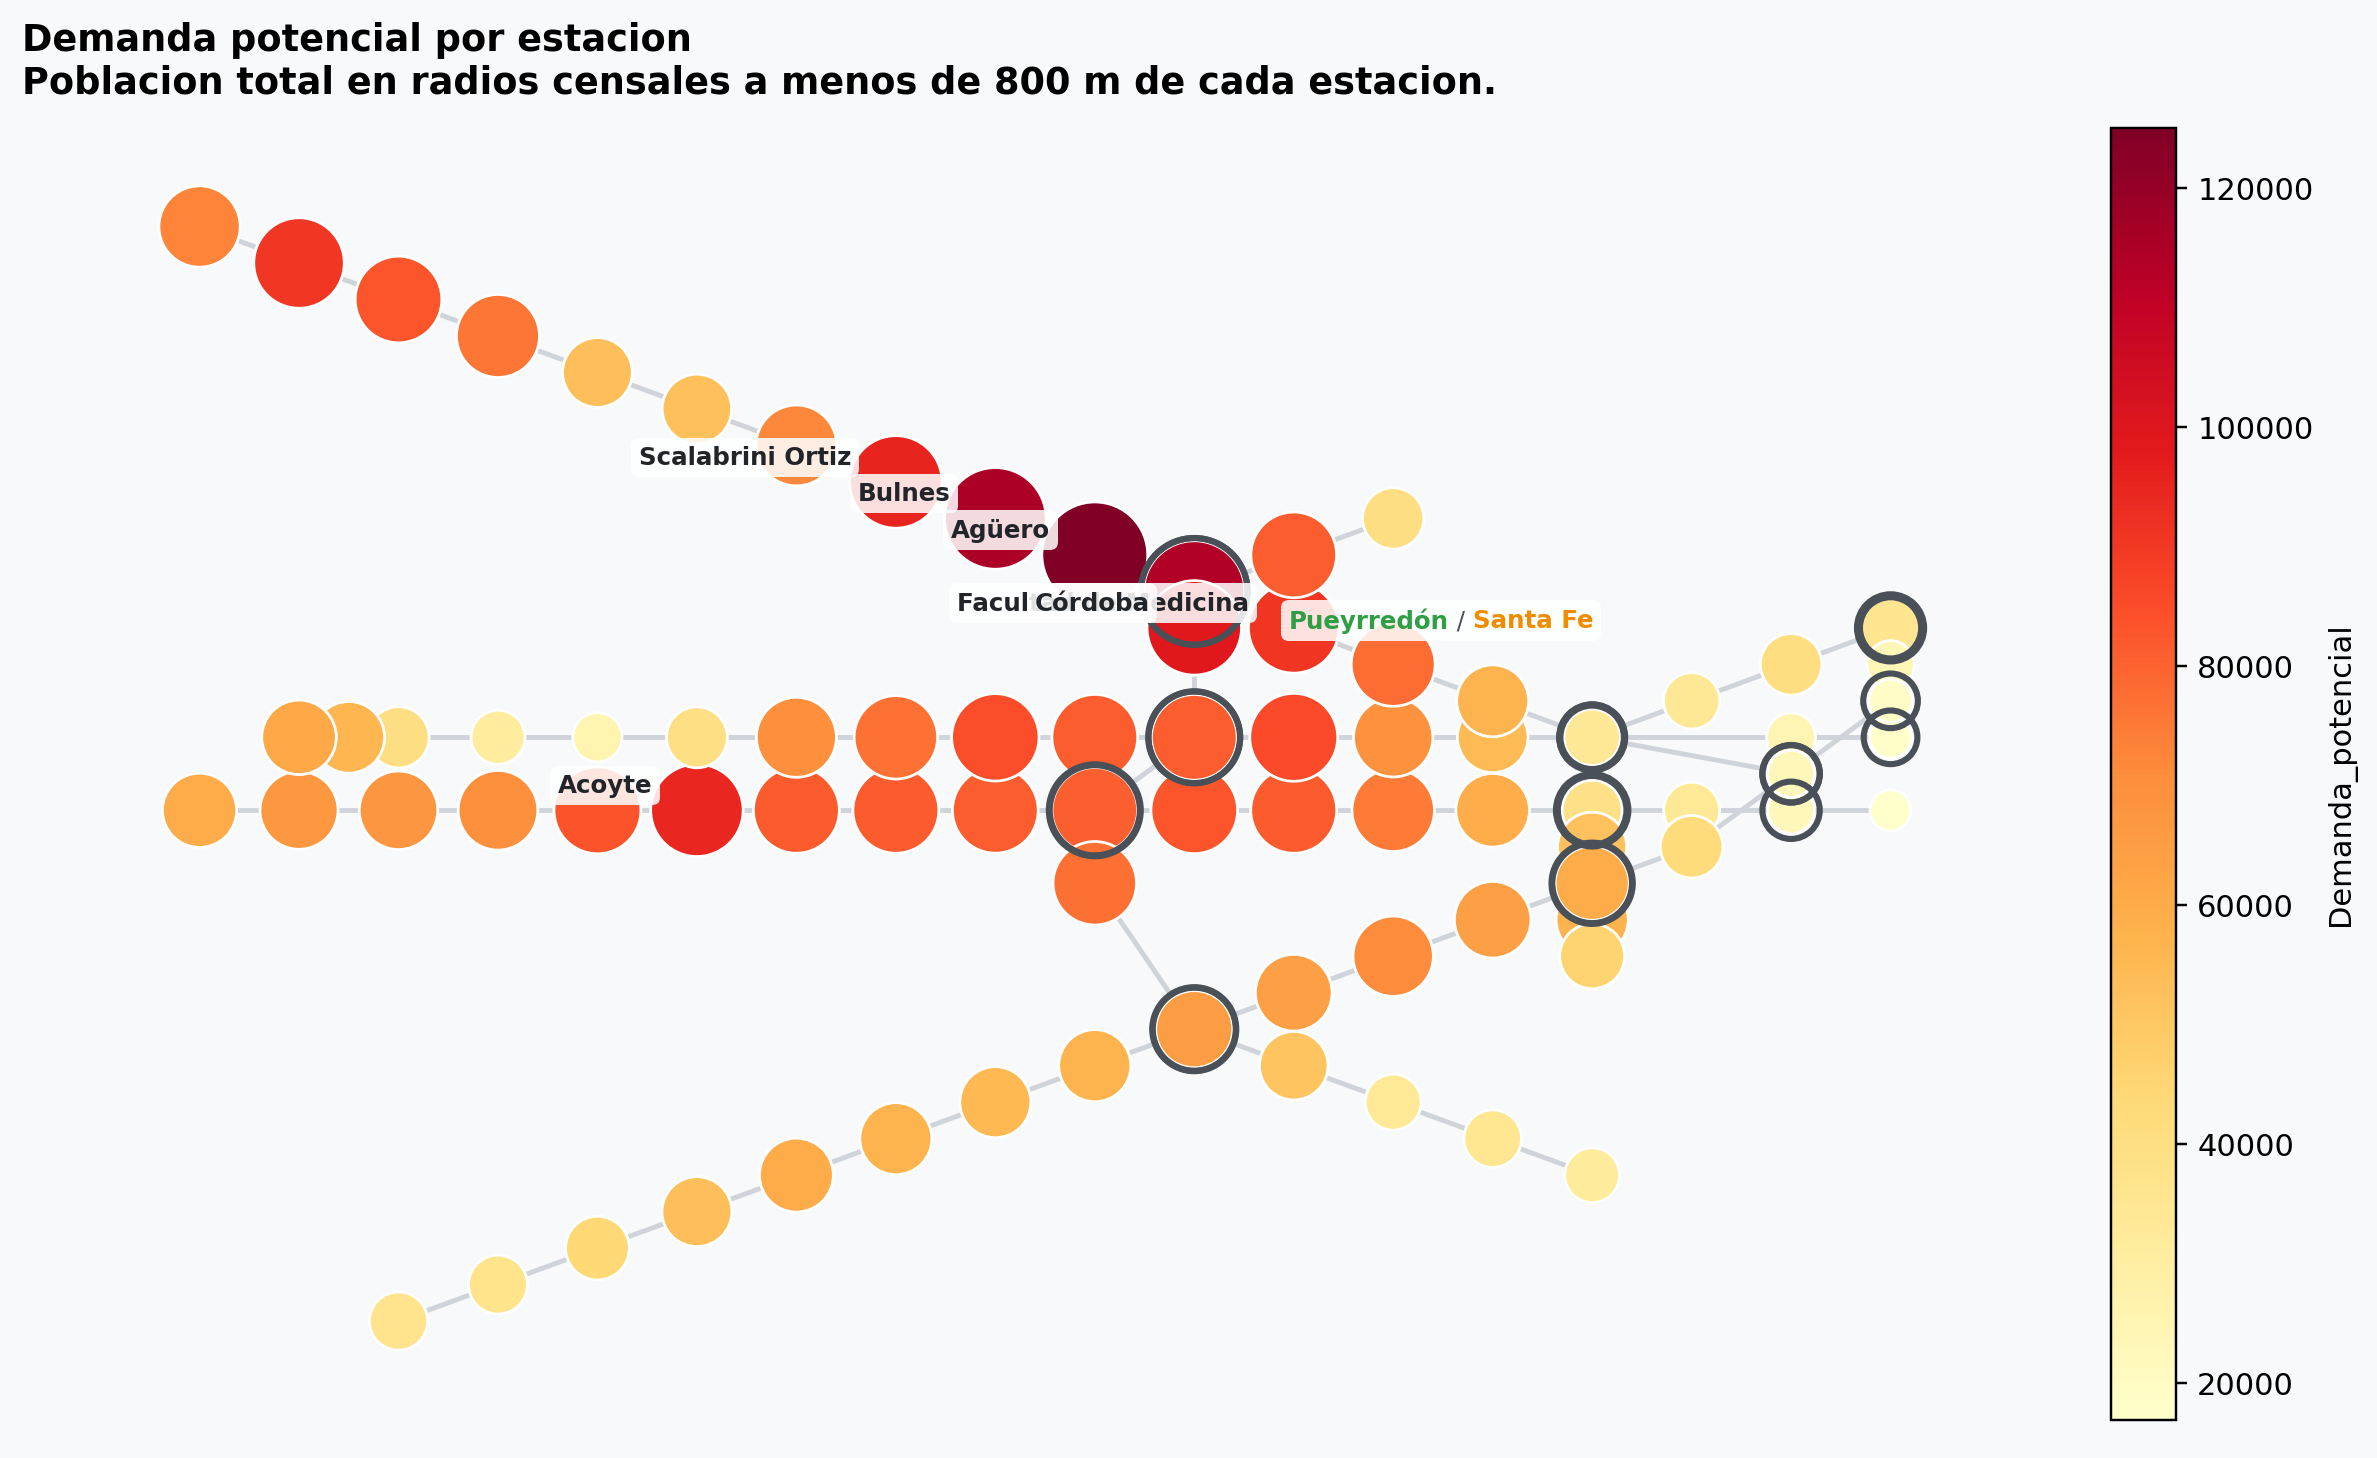

In [5]:
display(Image(filename=str(FIGURES_DIR / 'demanda_potencial_por_estacion.png')))

In [6]:
top_demand.assign(pasajeros_diarios_promedio=lambda df: df['pasajeros_diarios_promedio'].round(1))

,estacion,linea,demanda_potencial,pasajeros_diarios_promedio,radios_cubiertos
30,Agüero,D,125052,4804.2,148
42,Bulnes,D,115091,7927.2,141
9,Pueyrredón,D,114579,3596.3,138
7,Santa Fe,H,114052,6802.1,137
12,Córdoba,H,99144,4620.7,127
53,Scalabrini Ortiz,D,95064,5049.9,123
62,Acoyte,A,94821,8047.8,111
24,Facultad de Medicina,D,90884,8617.9,123
84,Juramento,D,90745,8194.4,124
17,Pasteur,B,85589,5645.7,119


In [7]:
pd.DataFrame(
    [
        {
            'hallazgo': 'eje con mayor mercado residencial',
            'lectura': 'predominan estaciones de lineas D y H entre los primeros puestos',
        },
        {
            'hallazgo': 'estacion con mayor demanda potencial',
            'lectura': 'Aguero (D), con 125.052 habitantes en radios a menos de 800 m',
        },
        {
            'hallazgo': 'limitacion central del indicador',
            'lectura': 'captura residencia cercana, pero no viajes de transbordo ni atraccion laboral/comercial',
        },
    ]
)

,hallazgo,lectura
0,eje con mayor mercado residencial,predominan estaciones de lineas D y H entre lo...
1,estacion con mayor demanda potencial,"Aguero (D), con 125.052 habitantes en radios a..."
2,limitacion central del indicador,"captura residencia cercana, pero no viajes de ..."


Lectura rapida:

- El mayor mercado residencial aparece sobre el corredor norte-centro de la linea D y en estaciones de la H con buena cobertura barrial.
- **Agüero**, **Bulnes**, **Pueyrredón (D)** y **Santa Fe (H)** resumen ese patron: mucha poblacion cercana y gran cantidad de radios cubiertos.
- El ranking ya anticipa un limite importante del ejercicio 2: estaciones muy centrales o de transbordo pueden mover muchos pasajeros aunque su entorno residencial inmediato no sea el mayor de la red.

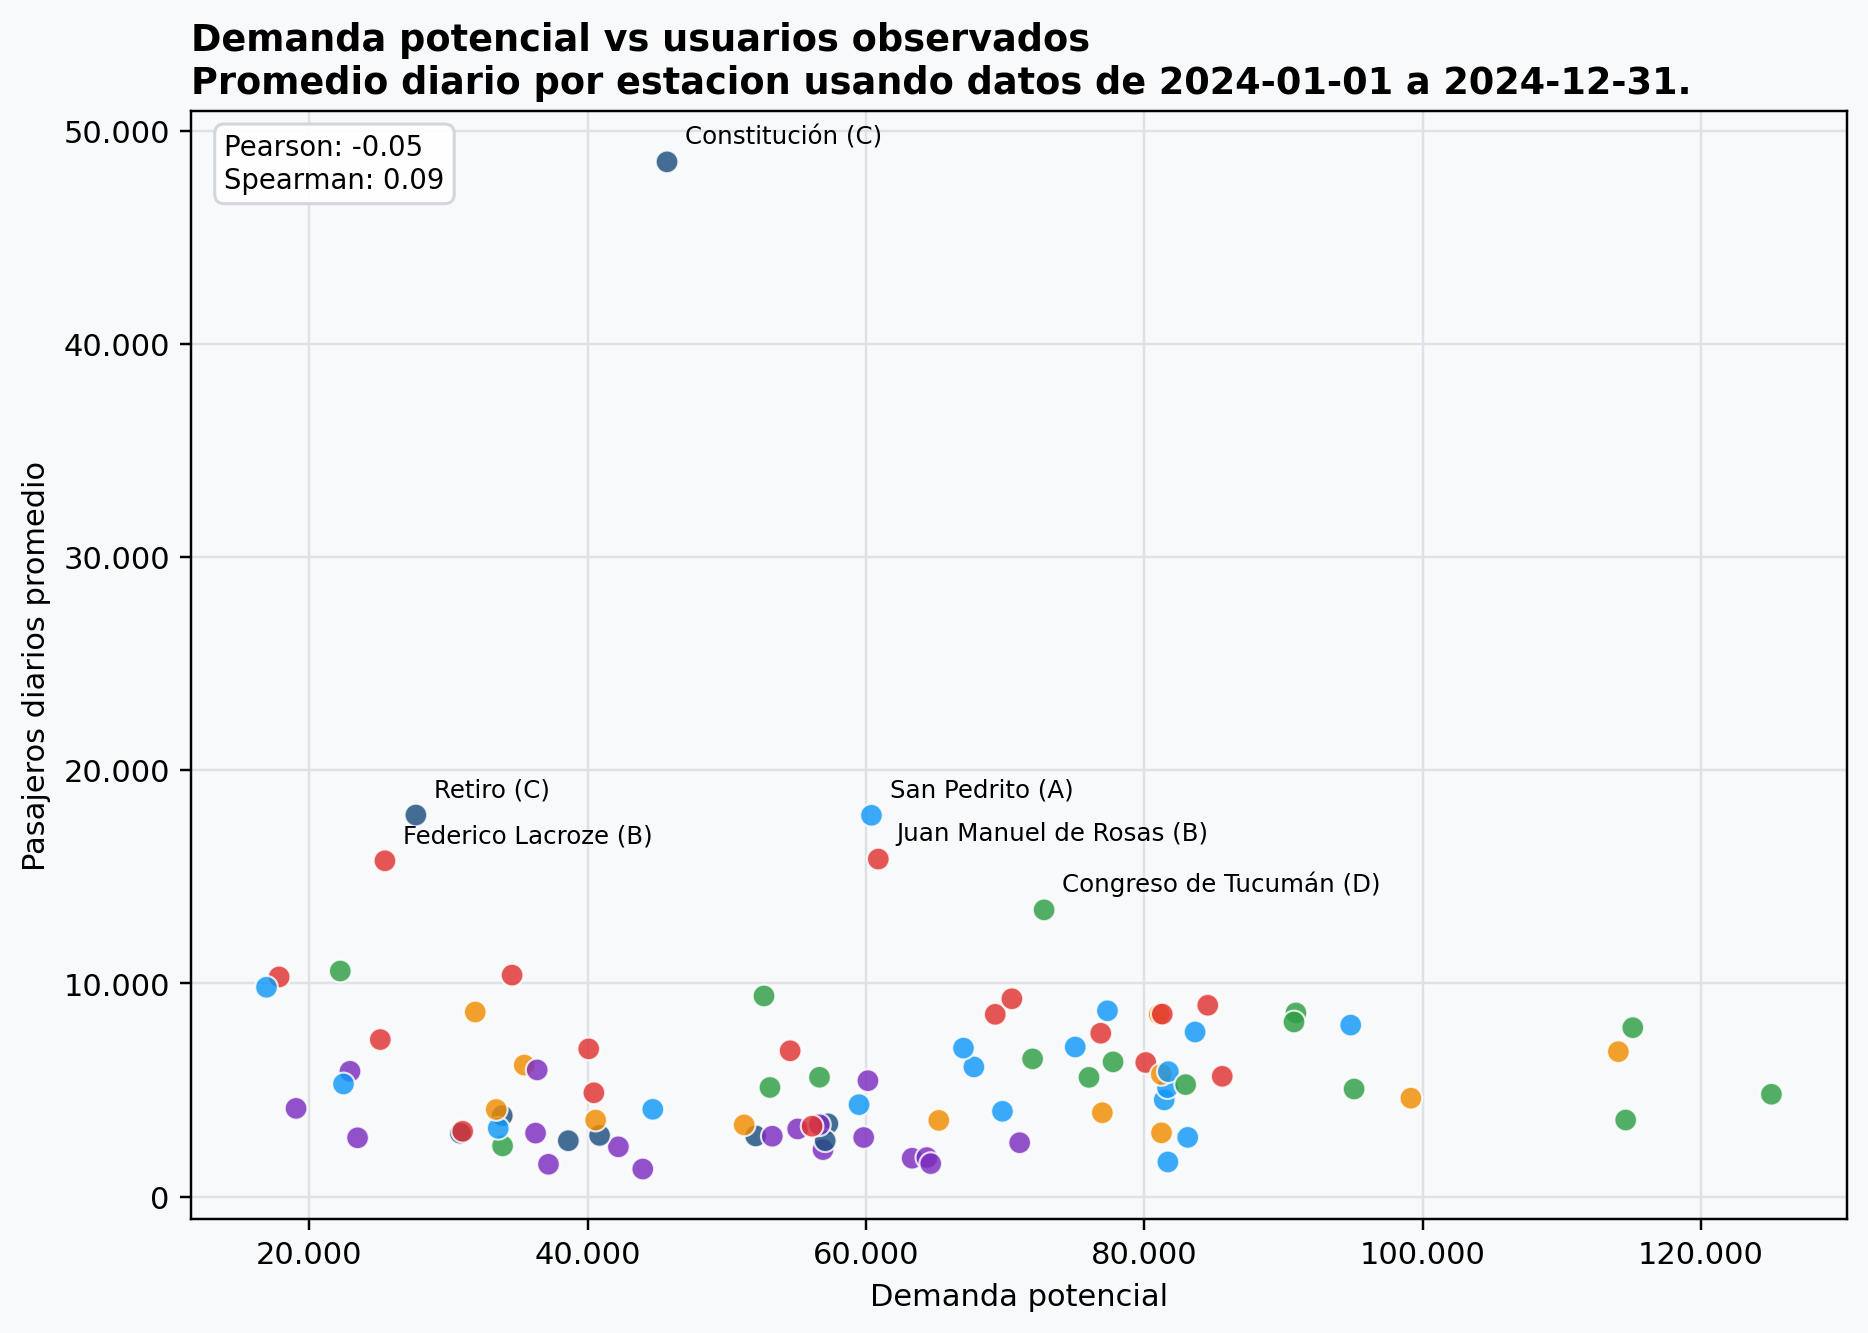

,comparacion,pearson,spearman
0,demanda_vs_molinetes,-0.054,0.095


In [8]:
display(Image(filename=str(FIGURES_DIR / 'demanda_vs_molinetes.png')))
correlations[correlations['comparacion'] == 'demanda_vs_molinetes'].assign(
    pearson=lambda df: df['pearson'].round(3),
    spearman=lambda df: df['spearman'].round(3),
)

La correlacion es deliberadamente baja y eso es un resultado util, no un error del modelo. El flujo real observado por molinetes depende de muchas cosas que el mercado residencial no captura: transbordos, viajes laborales, centralidad comercial, cabeceras y asimetrias de recorrido. En otras palabras, vivir cerca de una estacion ayuda, pero no alcanza para explicar por si solo cuanta gente entra por esa boca. Con el dataset 2024 esto se ve especialmente bien en `Plaza de Mayo`, `Retiro` o `Leandro N. Alem`, que aparecen muy arriba en molinetes aun cuando su mercado residencial inmediato es relativamente chico.

In [9]:
matched = station_metrics.dropna(subset=['pasajeros_diarios_promedio']).copy()
matched['rank_demanda'] = matched['demanda_potencial'].rank(ascending=False, method='min')
matched['rank_molinetes'] = matched['pasajeros_diarios_promedio'].rank(ascending=False, method='min')
matched['gap_molinetes_vs_demanda'] = matched['rank_demanda'] - matched['rank_molinetes']

display(
    matched.sort_values('gap_molinetes_vs_demanda', ascending=False)
    [[
        'estacion',
        'linea',
        'demanda_potencial',
        'pasajeros_diarios_promedio',
        'gap_molinetes_vs_demanda',
    ]]
    .head(6)
    .rename(columns={'gap_molinetes_vs_demanda': 'gap_rank'})
    .assign(pasajeros_diarios_promedio=lambda df: df['pasajeros_diarios_promedio'].round(1))
)

display(
    matched.sort_values('gap_molinetes_vs_demanda')
    [[
        'estacion',
        'linea',
        'demanda_potencial',
        'pasajeros_diarios_promedio',
        'gap_molinetes_vs_demanda',
    ]]
    .head(6)
    .rename(columns={'gap_molinetes_vs_demanda': 'gap_rank'})
    .assign(pasajeros_diarios_promedio=lambda df: df['pasajeros_diarios_promedio'].round(1))
)

,estacion,linea,demanda_potencial,pasajeros_diarios_promedio,gap_rank
14,Catedral,D,22213,10582.6,80.0
52,Leandro N. Alem,B,17820,10306.4,80.0
72,Plaza de Mayo,A,16911,9821.2,80.0
60,Retiro,C,27647,17899.8,79.0
68,Federico Lacroze,B,25422,15754.7,77.0
13,Carlos Pellegrini,B,34559,10392.1,65.0


,estacion,linea,demanda_potencial,pasajeros_diarios_promedio,gap_rank
39,Pasco,A,81685,1628.1,-71.0
32,Alberti,A,83110,2781.8,-63.0
9,Pueyrredón,D,114579,3596.3,-57.0
0,Corrientes,H,81224,2994.6,-50.0
38,Pichincha,E,64642,1551.6,-49.0
36,Entre Ríos,E,71033,2532.2,-49.0


### Modelo OD con demanda

Para el modelo de gravedad del ejercicio 2 se usa

`P(i->j) = C * D_i * D_j * exp(-d_ij / d0)`

con `d0 = 15 min`. La tabla compara el escenario sin peso con el escenario ponderado por demanda. Debajo aparece el ranking de estaciones con mayor betweenness bajo ese modelo de flujos.

La intuicion es simple: cuando los viajes probables se concentran en origenes y destinos densamente poblados, el promedio de tiempos cae porque el modelo deja de repartir viajes con la misma importancia entre pares muy perifericos y pares muy centrales.

In [10]:
model_summary.iloc[:2].assign(
    tiempo_medio=lambda df: df['tiempo_medio'].round(2),
    delta_vs_sin_peso_pct=lambda df: df['delta_vs_sin_peso_pct'].round(2),
)

,escenario,tiempo_medio,delta_vs_sin_peso_pct
0,Sin peso,23.51,0.00
1,Demanda potencial,15.99,-32.01


In [11]:
top_betweenness_demand.assign(
    betweenness_uniforme=lambda df: df['betweenness_uniforme'].round(4),
    betweenness_demanda=lambda df: df['betweenness_demanda'].round(4),
    cambio_demanda_vs_uniforme=lambda df: df['cambio_demanda_vs_uniforme'].round(4),
)

,estacion,linea,betweenness_uniforme,betweenness_demanda,cambio_demanda_vs_uniforme
0,Corrientes,H,0.3181,0.2764,-0.0418
2,Once,H,0.3283,0.2716,-0.0566
11,Plaza Miserere,A,0.2313,0.1970,-0.0342
9,Pueyrredón,D,0.2356,0.1885,-0.0471
4,Pueyrredón,B,0.2493,0.1714,-0.0779
12,Córdoba,H,0.1758,0.1630,-0.0127
7,Santa Fe,H,0.1851,0.1615,-0.0236
6,Humberto 1º,H,0.2276,0.1508,-0.0768
10,Venezuela,H,0.2031,0.1463,-0.0568
15,Jujuy,E,0.2263,0.1360,-0.0904


Bajo este modelo, las estaciones puente siguen siendo casi las mismas que en el ejercicio 1, pero su peso relativo cambia. Los nodos de la H y los grandes intercambios del corredor central continúan arriba, aunque con betweenness algo menor que en el caso sin peso: la demanda potencial acerca parte de los viajes a zonas con mucha poblacion y reduce el protagonismo de algunos trayectos muy largos o poco probables.

## 3. Ejercicio 3: atraccion de cada estacion

Se eligieron tres conjuntos de puntos de interes para caracterizar la atraccion urbana inmediata de cada estacion. Esos POI se descargan desde OpenStreetMap via Overpass API, en linea con la consigna del trabajo, y luego se agregan por estacion dentro de un radio de `400 m`:

- educacion,
- salud,
- comercio.

Cada mapa muestra cuantos POI de esa categoria quedan dentro de `400 m` de la estacion.

Aca el supuesto es deliberadamente simple: cada POI suma una unidad, sin ponderar tamano ni jerarquia. Eso vuelve al indicador facil de leer y comparable entre estaciones, aunque tambien obliga a interpretar `atraccion_total` como una proxy de diversidad/intensidad urbana cercana y no como una medida exacta de viajes atraidos. En terminos de fuente, entonces, el ejercicio 3 si usa datos de OpenStreetMap: lo que simplificamos no es el origen de los datos sino la forma de agregarlos.

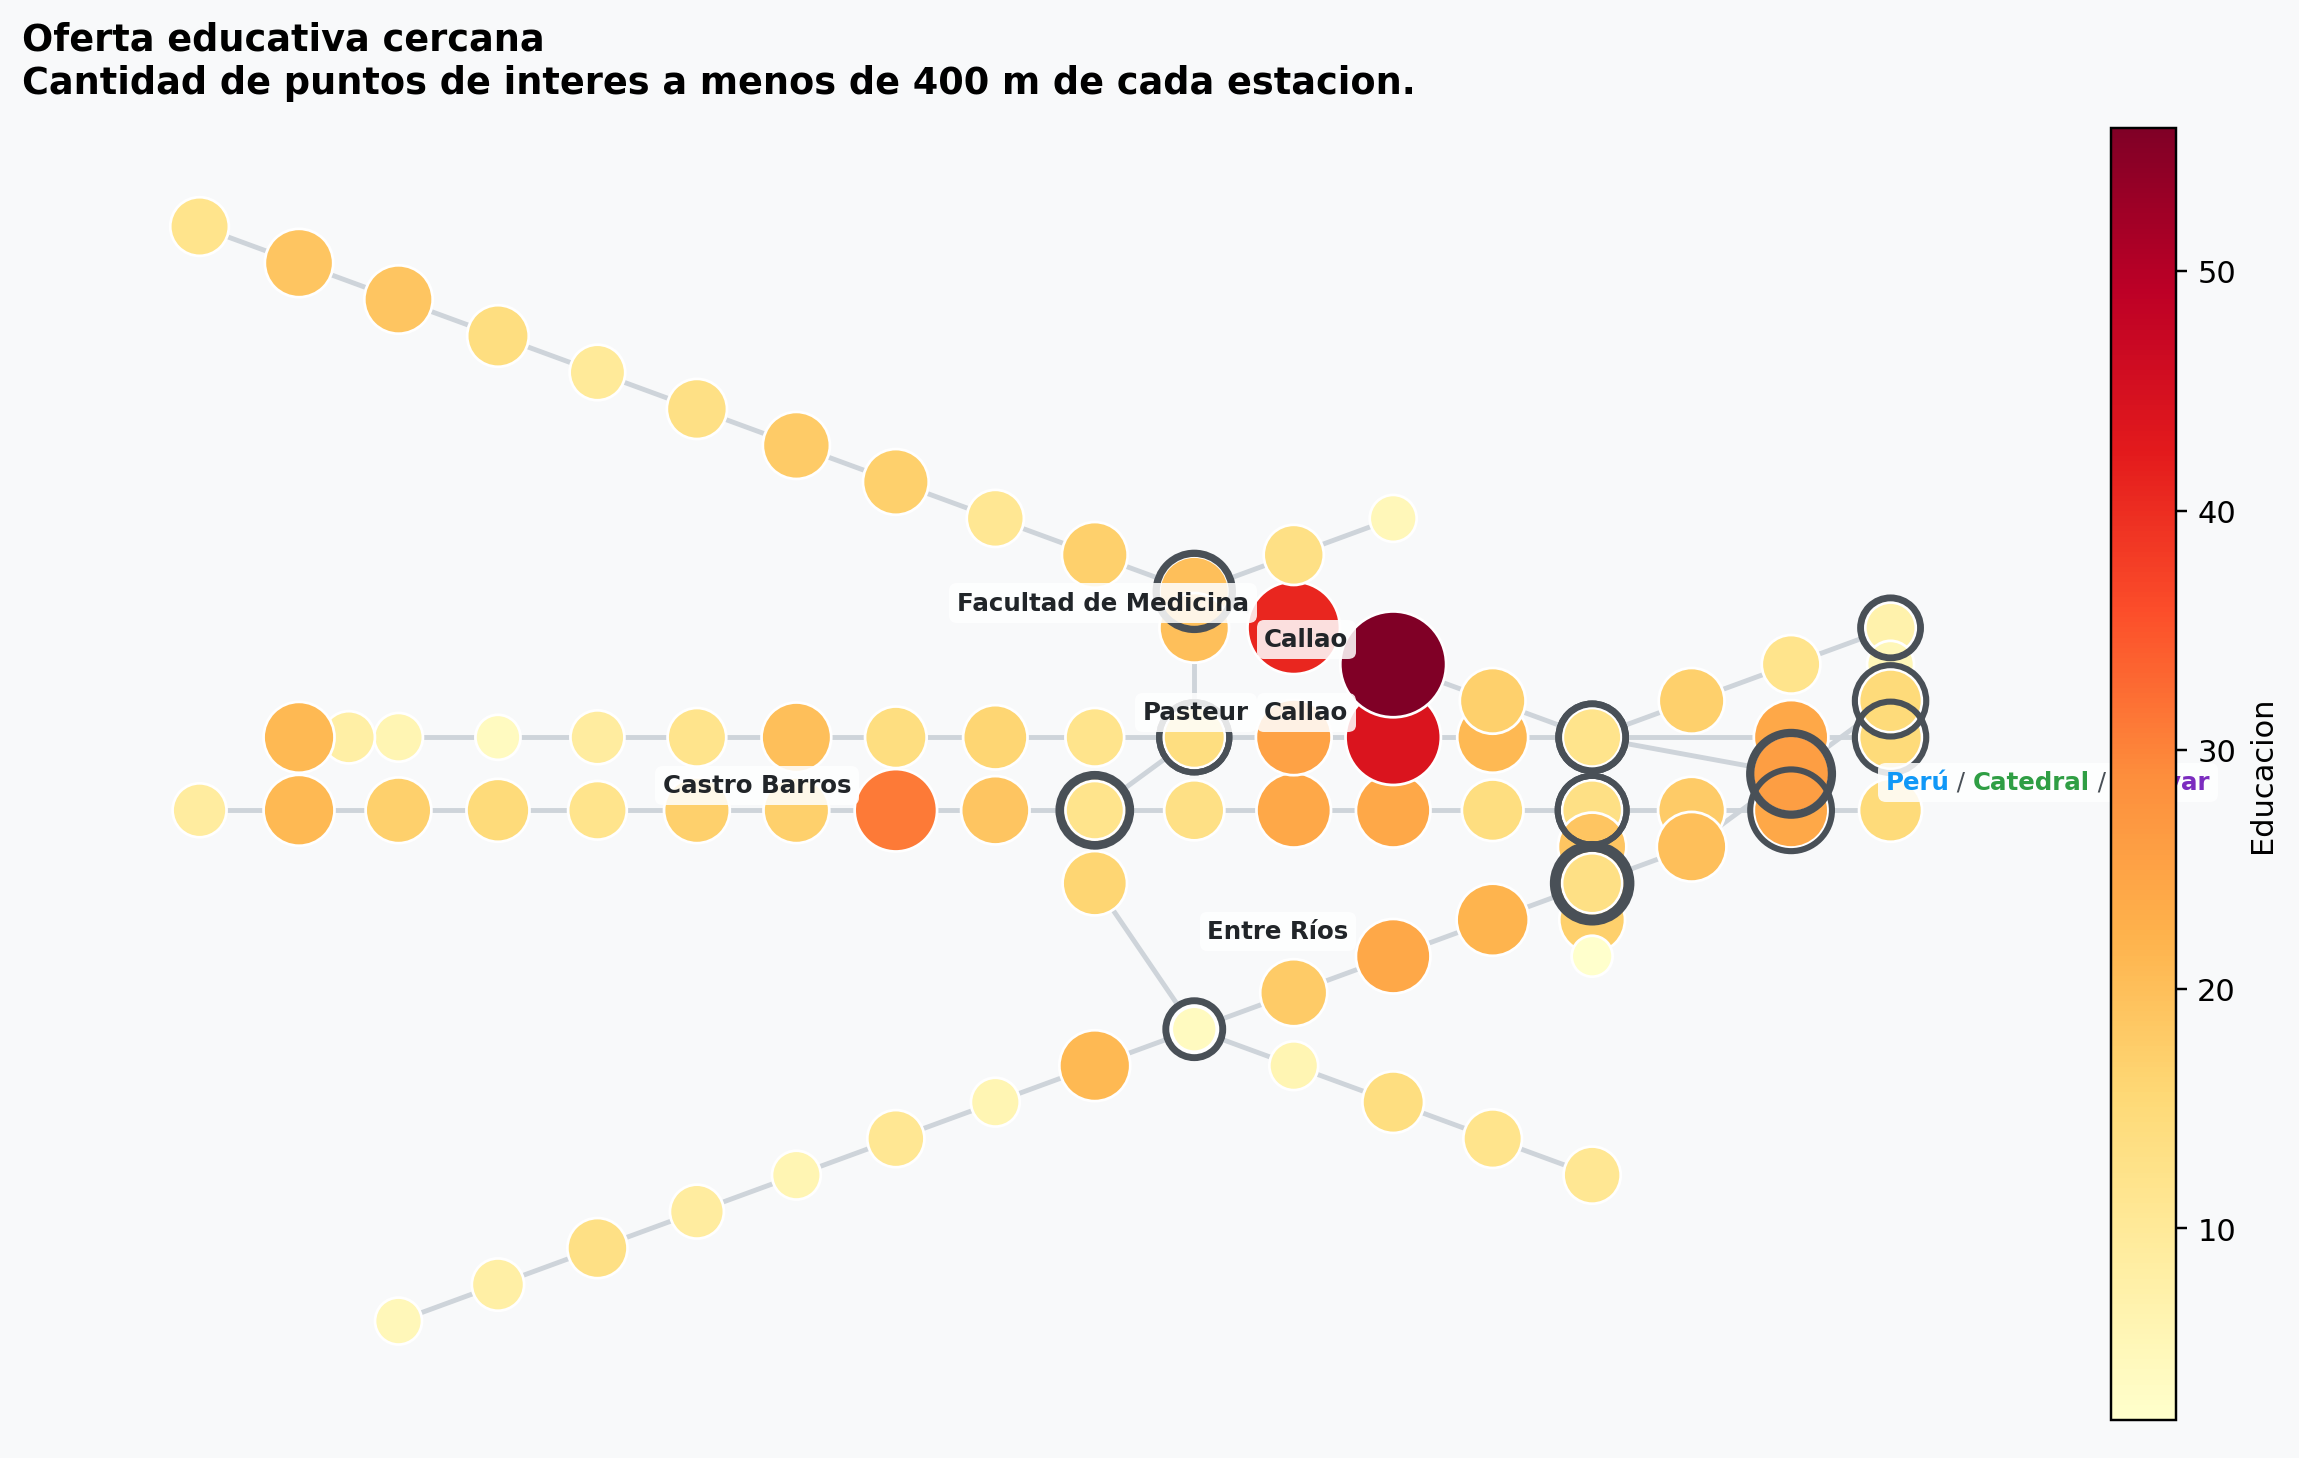

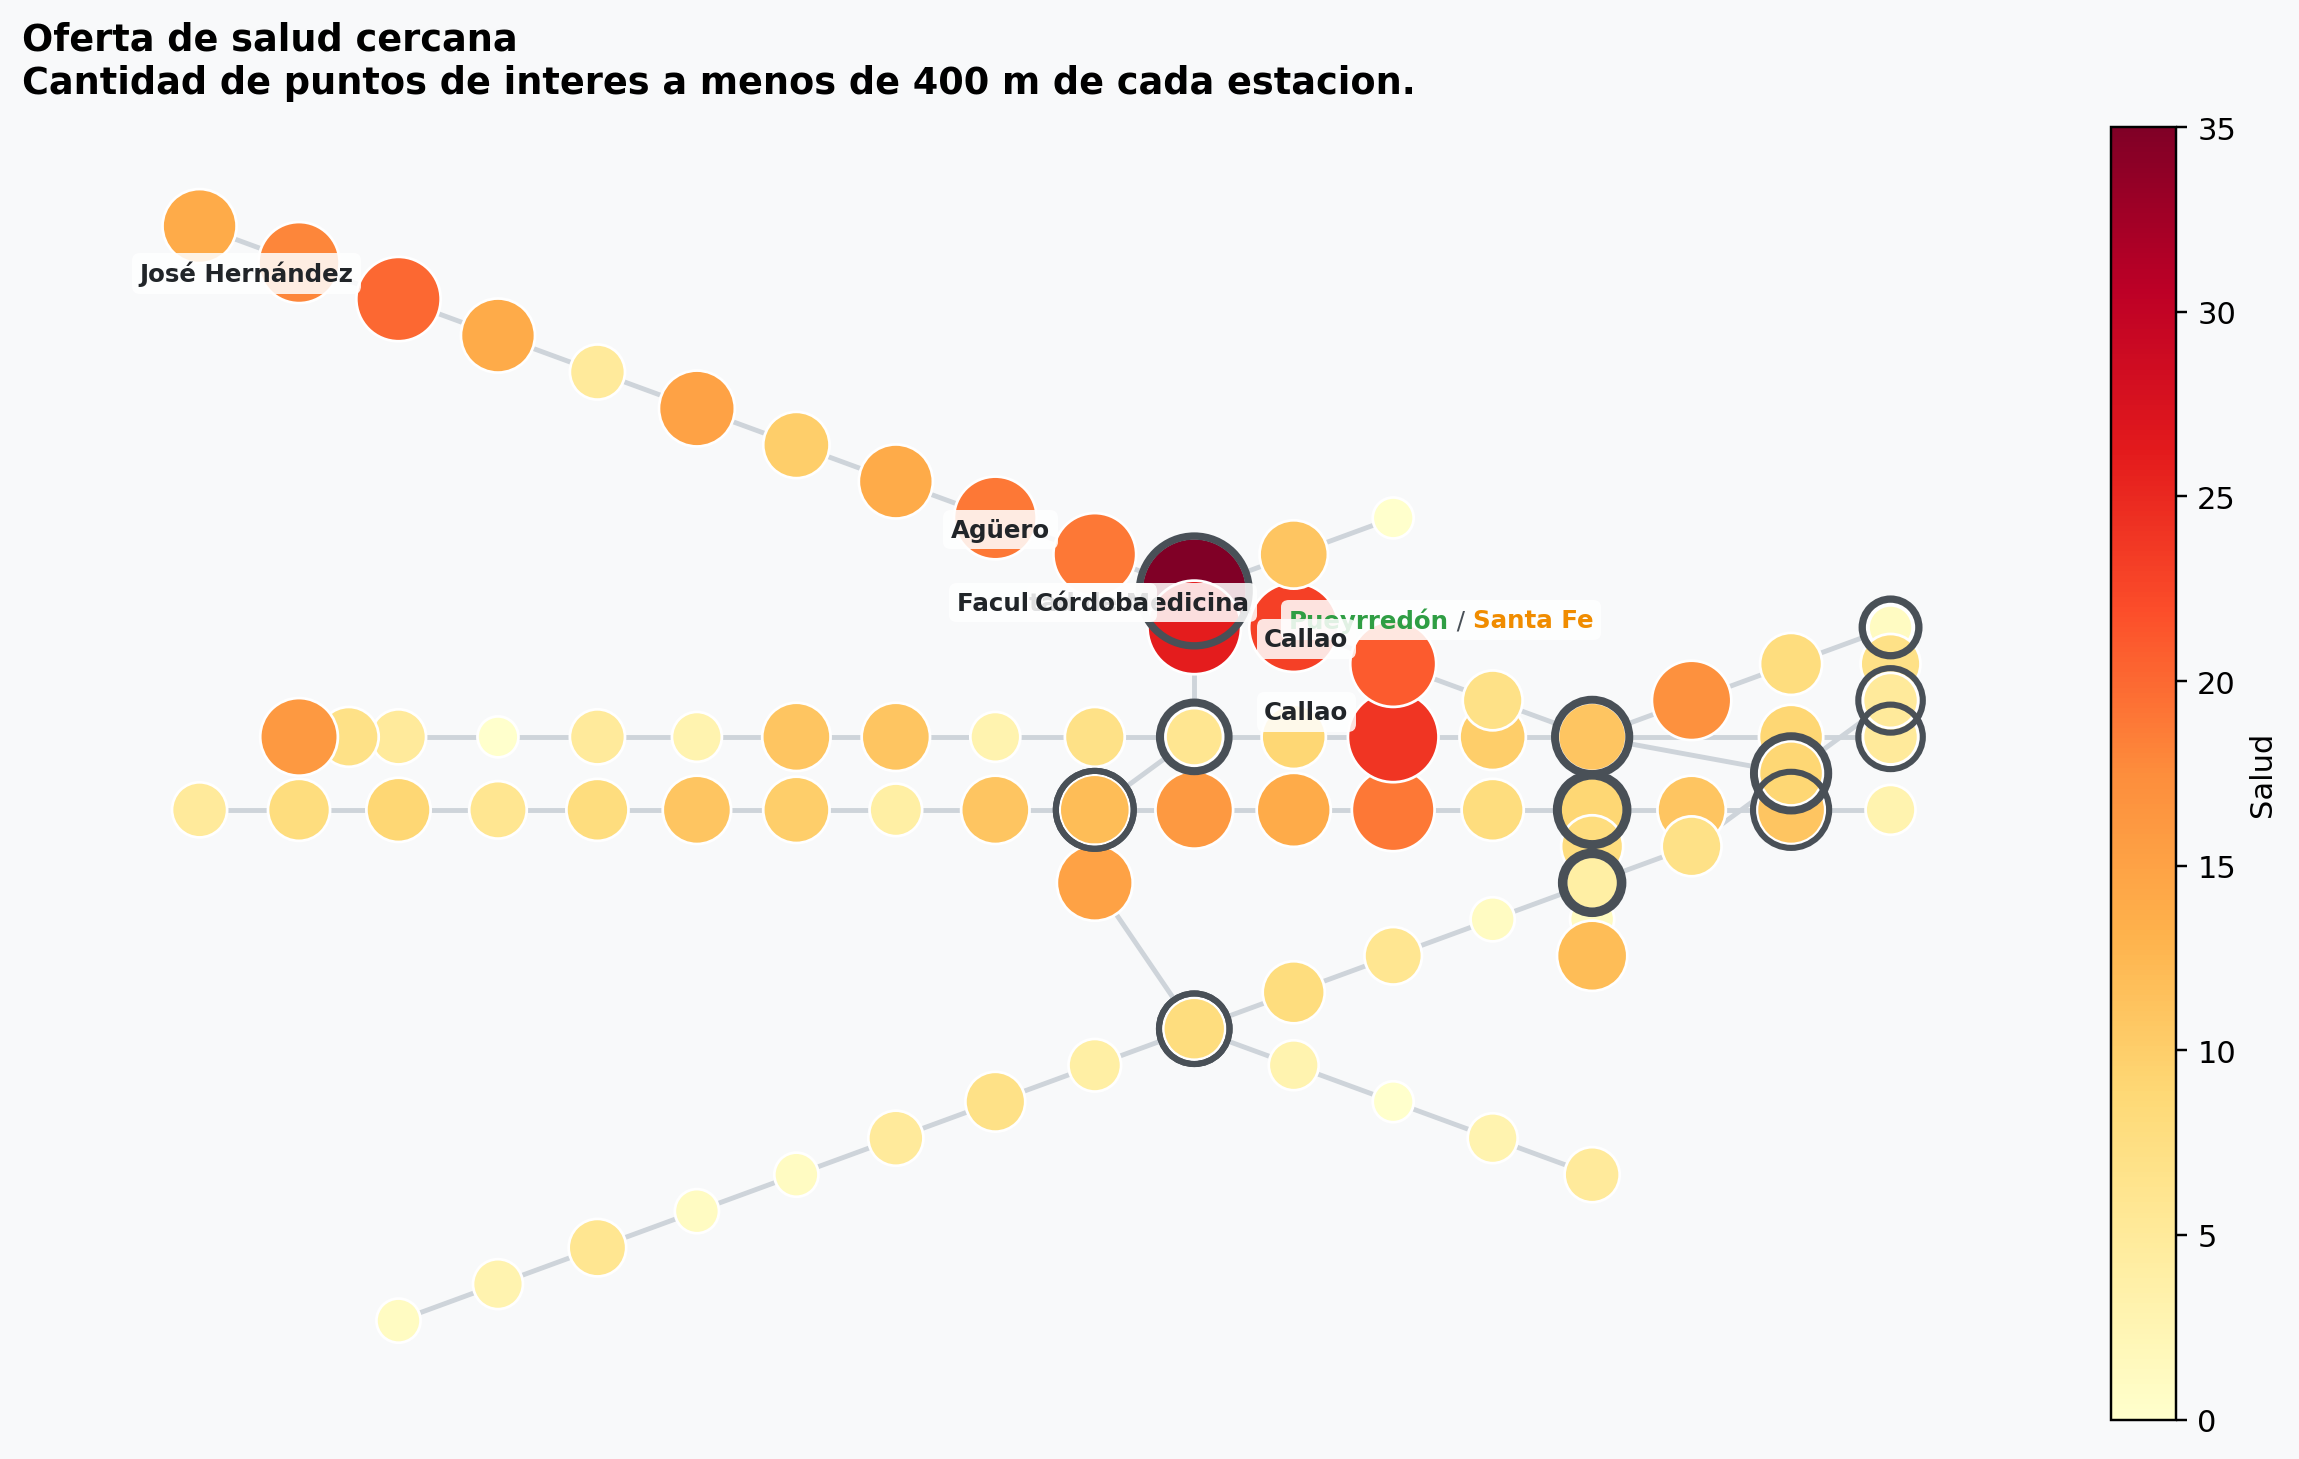

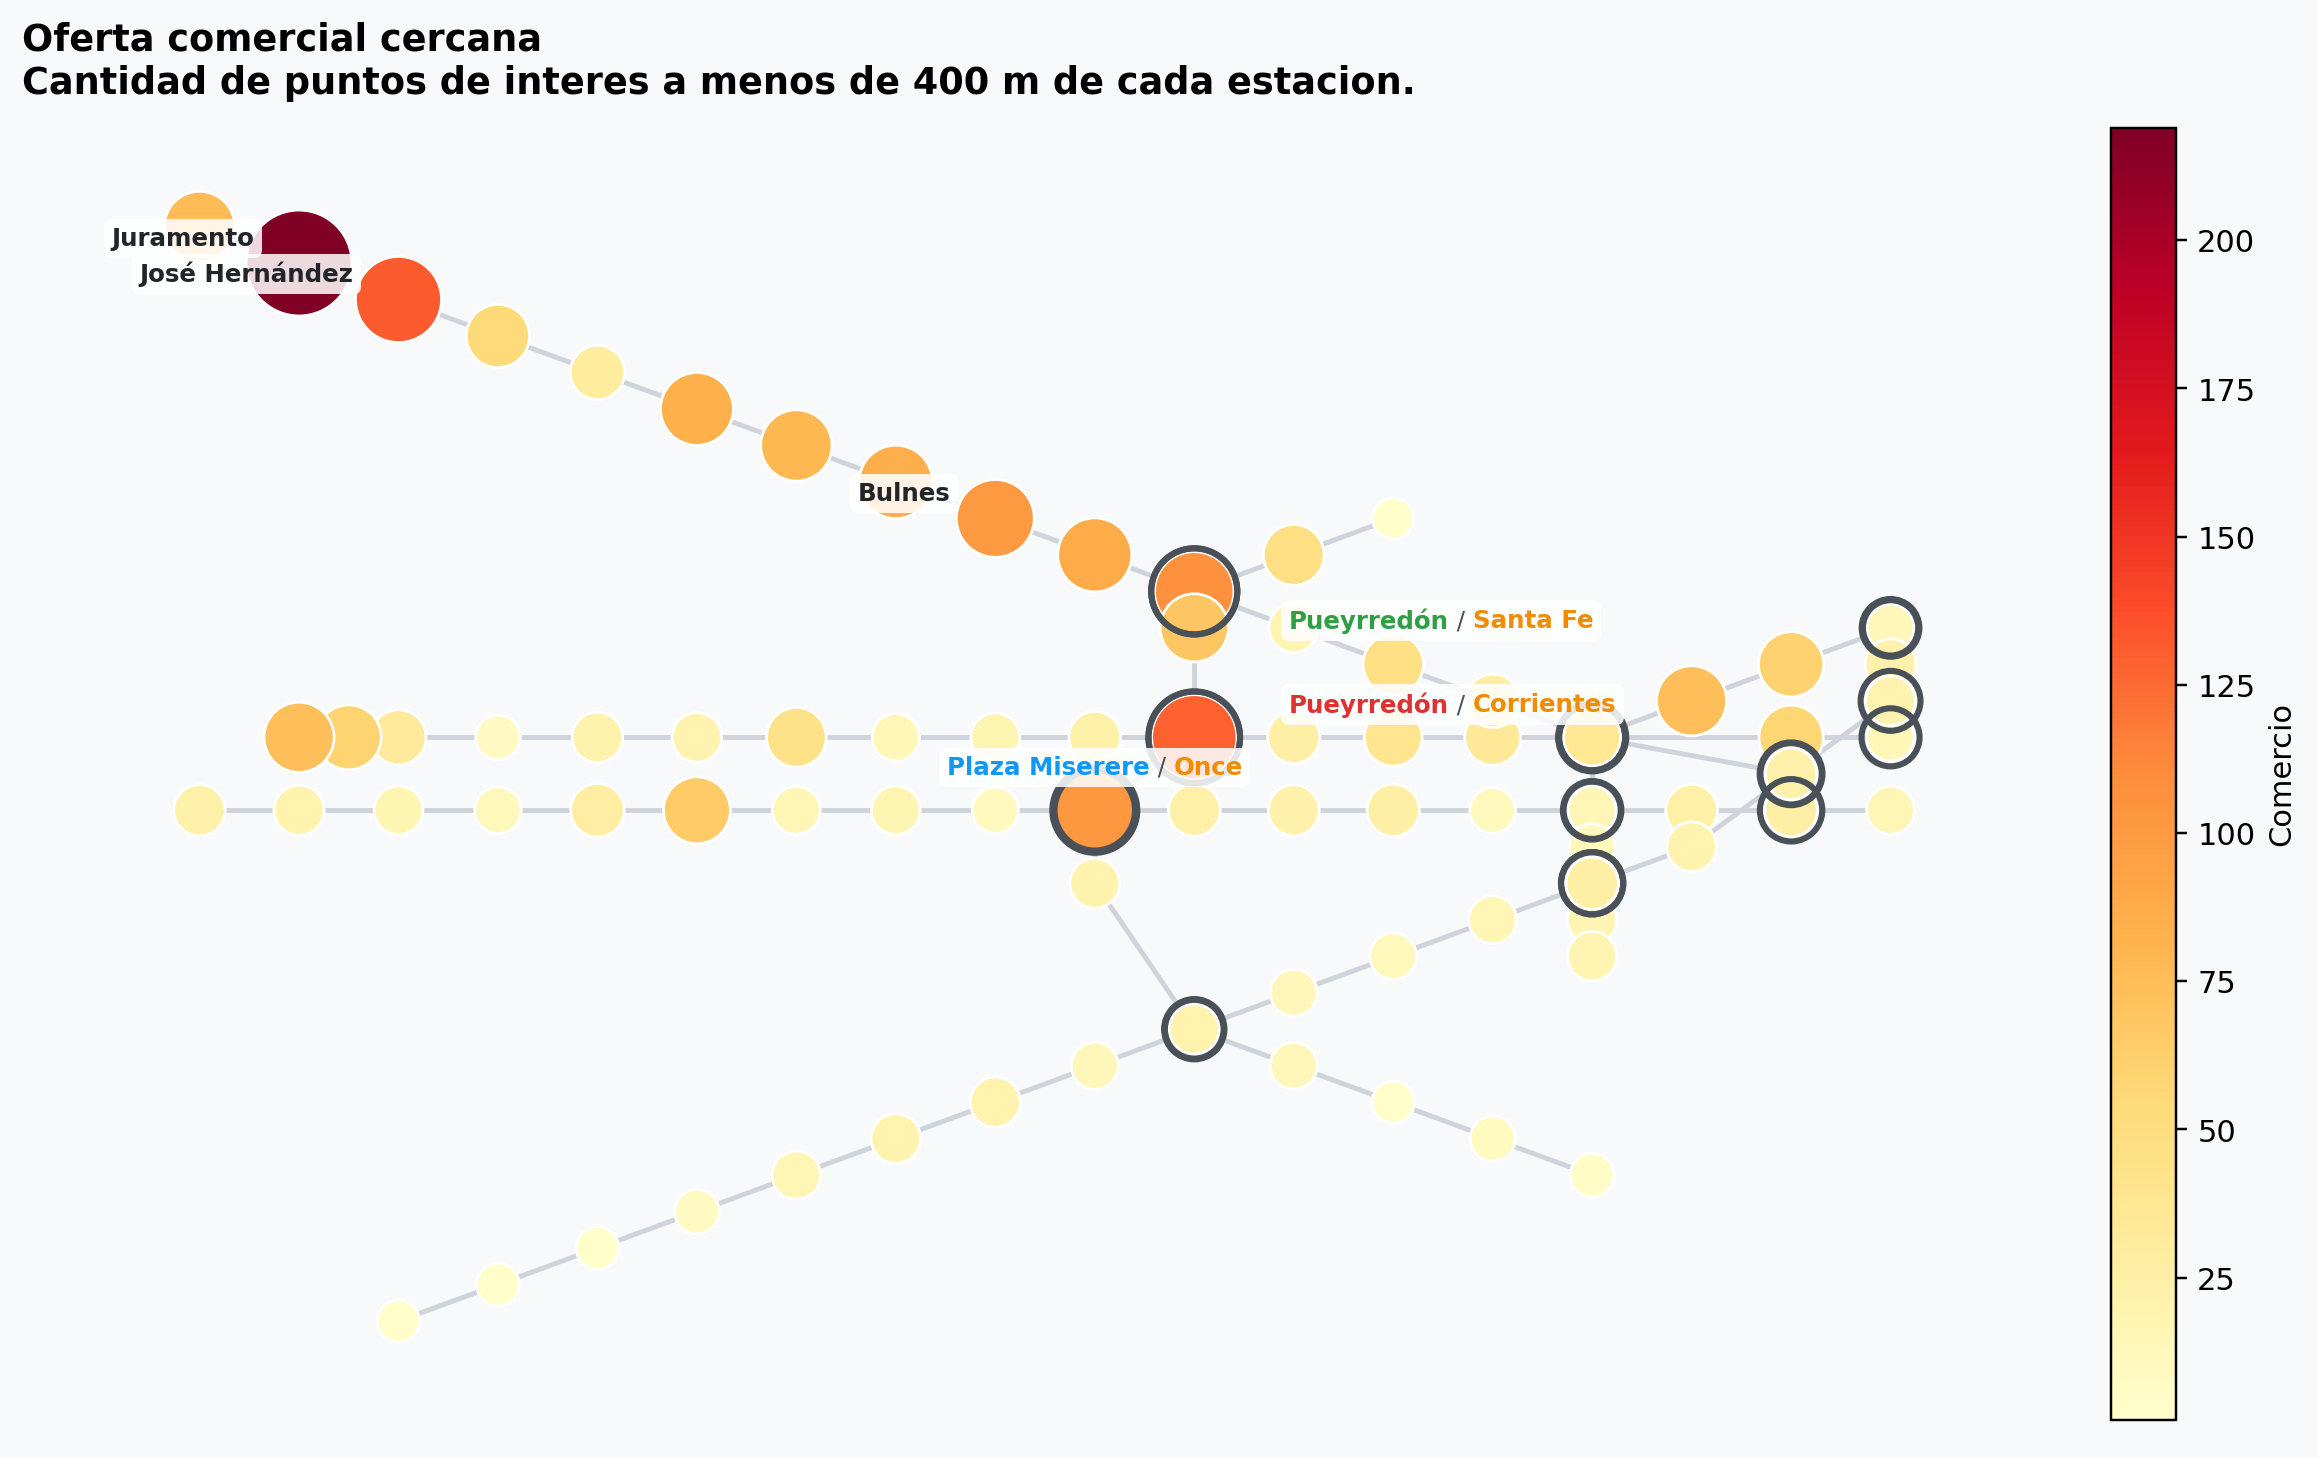

In [12]:
display(Image(filename=str(FIGURES_DIR / 'poi_educacion_por_estacion.png')))
display(Image(filename=str(FIGURES_DIR / 'poi_salud_por_estacion.png')))
display(Image(filename=str(FIGURES_DIR / 'poi_comercio_por_estacion.png')))

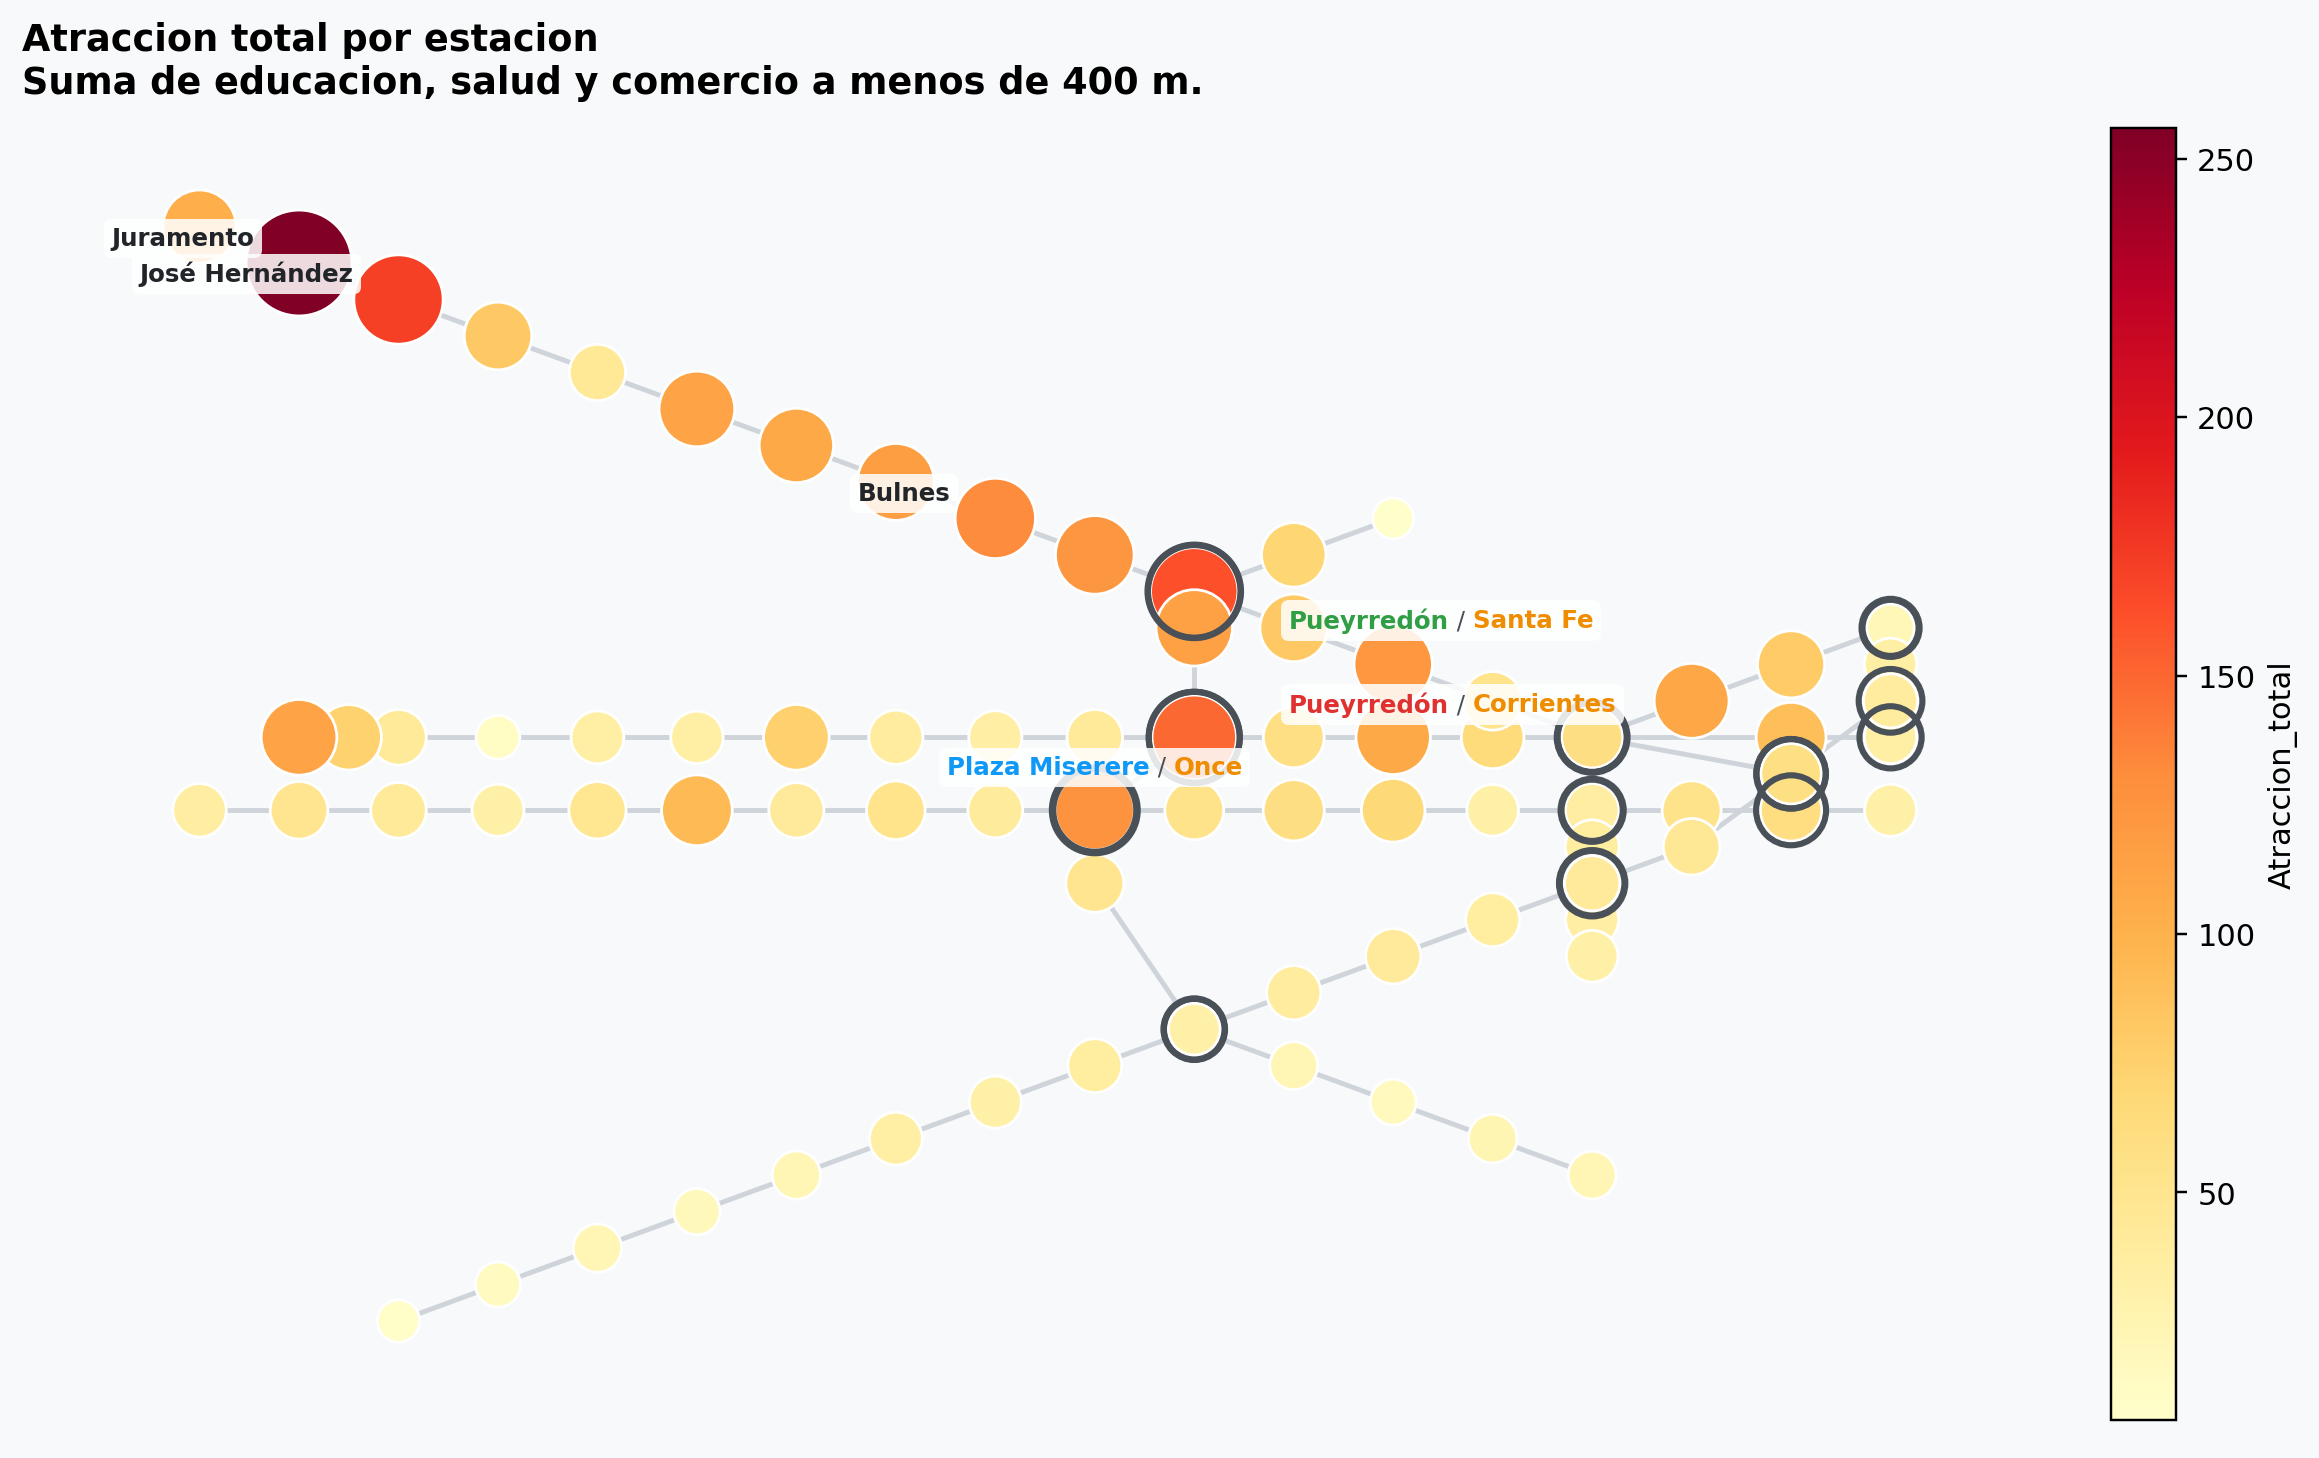

,estacion,linea,atraccion_total,educacion,salud,comercio,pasajeros_diarios_promedio
84,Juramento,D,256,19,18,219,8194.4
79,José Hernández,D,171,19,20,132,5256.8
7,Santa Fe,H,162,20,35,107,6802.1
9,Pueyrredón,D,157,18,33,106,3596.3
4,Pueyrredón,B,151,14,8,129,6294.7
0,Corrientes,H,149,14,6,129,2994.6
42,Bulnes,D,131,11,19,101,7927.2
2,Once,H,126,12,12,102,8553.0
30,Agüero,D,124,17,19,88,4804.2
28,Callao,D,123,56,21,46,6321.4


In [13]:
display(Image(filename=str(FIGURES_DIR / 'atraccion_total_por_estacion.png')))
top_attraction.assign(pasajeros_diarios_promedio=lambda df: df['pasajeros_diarios_promedio'].round(1))

Lectura rapida:

- La atraccion total queda dominada por corredores comerciales de la linea D y por nodos mixtos del eje H.
- **Juramento** y **José Hernández** destacan sobre todo por comercio, mientras que **Callao (D)** aparece muy arriba porque combina un perfil comercial con una oferta educativa especialmente intensa.
- En varias estaciones centrales la atraccion supera claramente a la demanda residencial cercana; eso sugiere destinos urbanos fuertes aun cuando el entorno inmediato no concentre la mayor poblacion de la red.

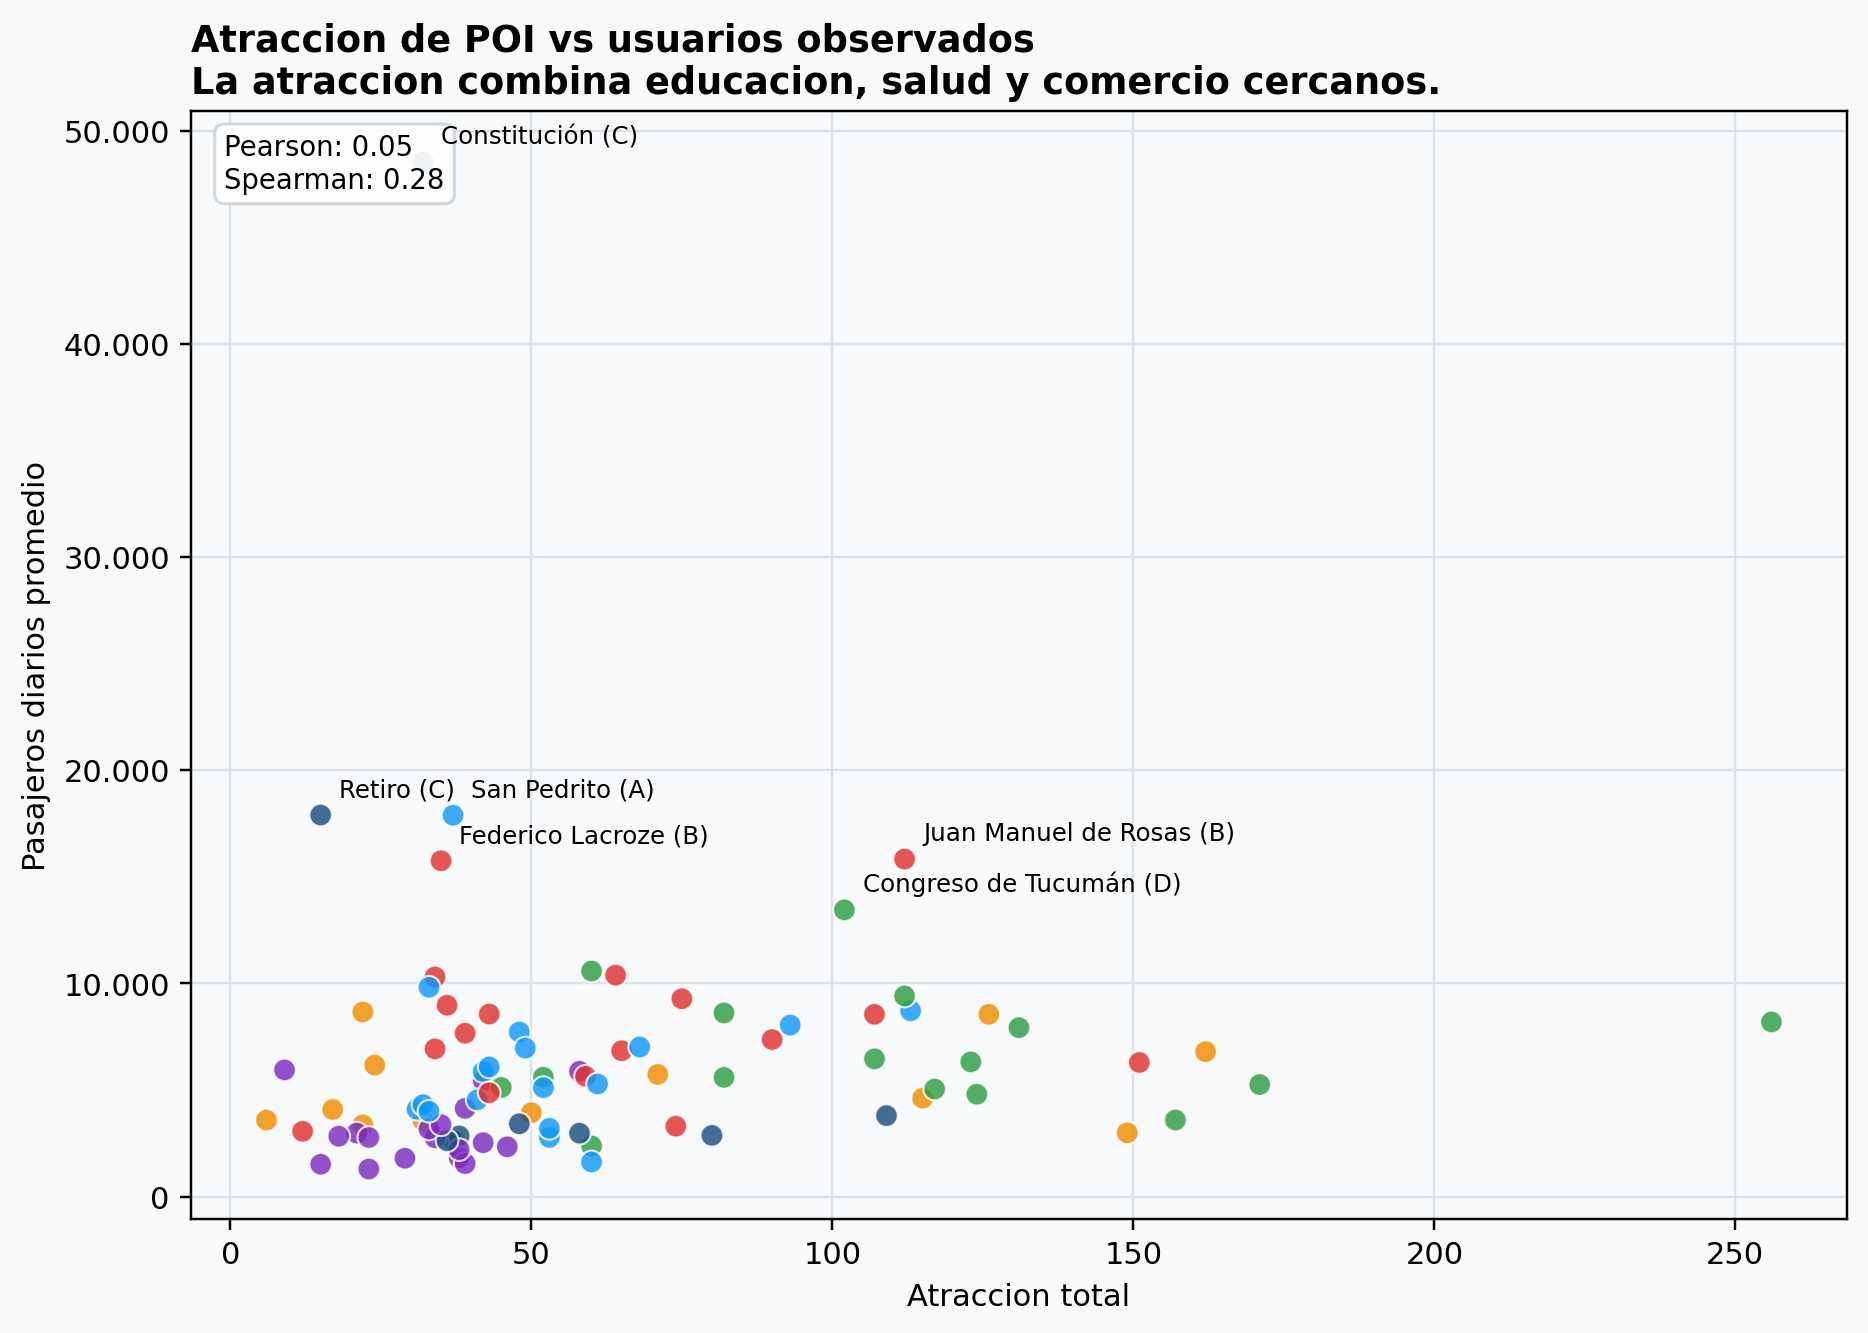

,comparacion,pearson,spearman
1,atraccion_vs_molinetes,0.052,0.284


In [14]:
display(Image(filename=str(FIGURES_DIR / 'atraccion_vs_molinetes.png')))
correlations[correlations['comparacion'] == 'atraccion_vs_molinetes'].assign(
    pearson=lambda df: df['pearson'].round(3),
    spearman=lambda df: df['spearman'].round(3),
)

La relacion directa entre atraccion y molinetes tambien es debil, aunque el orden por rangos mejora un poco respecto de la demanda residencial. Eso es consistente con la intuicion urbana: los POI ayudan a distinguir destinos activos, pero siguen dejando afuera factores como la funcion de transbordo, la conectividad de red y la direccion dominante de los viajes. Casos como `Constitucion`, `Retiro` o `Plaza de Mayo` sugieren ademas que nuestra proxy de atraccion no captura del todo funciones terminales, civicas e institucionales que tambien generan viajes.

In [15]:
matched = station_metrics.dropna(subset=['pasajeros_diarios_promedio']).copy()
matched['rank_atraccion'] = matched['atraccion_total'].rank(ascending=False, method='min')
matched['rank_molinetes'] = matched['pasajeros_diarios_promedio'].rank(ascending=False, method='min')
matched['gap_molinetes_vs_atraccion'] = matched['rank_atraccion'] - matched['rank_molinetes']

display(
    matched.sort_values('gap_molinetes_vs_atraccion', ascending=False)
    [[
        'estacion',
        'linea',
        'atraccion_total',
        'pasajeros_diarios_promedio',
        'gap_molinetes_vs_atraccion',
    ]]
    .head(6)
    .rename(columns={'gap_molinetes_vs_atraccion': 'gap_rank'})
    .assign(pasajeros_diarios_promedio=lambda df: df['pasajeros_diarios_promedio'].round(1))
)

display(
    matched.sort_values('gap_molinetes_vs_atraccion')
    [[
        'estacion',
        'linea',
        'atraccion_total',
        'pasajeros_diarios_promedio',
        'gap_molinetes_vs_atraccion',
    ]]
    .head(6)
    .rename(columns={'gap_molinetes_vs_atraccion': 'gap_rank'})
    .assign(pasajeros_diarios_promedio=lambda df: df['pasajeros_diarios_promedio'].round(1))
)

,estacion,linea,atraccion_total,pasajeros_diarios_promedio,gap_rank
60,Retiro,C,15,17899.8,84.0
80,Constitución,C,32,48533.2,72.0
85,Hospitales,H,22,8660.8,66.0
68,Federico Lacroze,B,35,15754.7,60.0
72,Plaza de Mayo,A,33,9821.2,60.0
52,Leandro N. Alem,B,34,10306.4,58.0


,estacion,linea,atraccion_total,pasajeros_diarios_promedio,gap_rank
0,Corrientes,H,149,2994.6,-64.0
9,Pueyrredón,D,157,3596.3,-56.0
39,Pasco,A,60,1628.1,-55.0
1,9 de Julio,D,60,2382.2,-50.0
50,General San Martín,C,80,2874.9,-49.0
37,Lavalle,C,109,3802.2,-43.0


### Modelo OD con demanda y atraccion

En el segundo modelo de gravedad se reemplaza la masa de destino por la atraccion observada alrededor de la estacion:

`P'(i->j) = C * D_i * O_j * exp(-d_ij / d0)`

La tabla final resume los tres escenarios y el ranking muestra que estaciones concentran mas intermediacion cuando el destino depende de la atraccion urbana y no solo de la poblacion residente.

Conceptualmente, este tercer paso sirve para probar si la red cambia cuando los destinos mas probables dejan de ser solo los lugares con mas poblacion y pasan a ser tambien los lugares con mas actividad cercana.

In [16]:
model_summary.assign(
    tiempo_medio=lambda df: df['tiempo_medio'].round(2),
    delta_vs_sin_peso_pct=lambda df: df['delta_vs_sin_peso_pct'].round(2),
)

,escenario,tiempo_medio,delta_vs_sin_peso_pct
0,Sin peso,23.51,0.00
1,Demanda potencial,15.99,-32.01
2,Demanda y atraccion,15.88,-32.45


In [17]:
top_betweenness_attraction.assign(
    betweenness_demanda=lambda df: df['betweenness_demanda'].round(4),
    betweenness_atraccion=lambda df: df['betweenness_atraccion'].round(4),
    cambio_atraccion_vs_demanda=lambda df: df['cambio_atraccion_vs_demanda'].round(4),
)

,estacion,linea,betweenness_demanda,betweenness_atraccion,cambio_atraccion_vs_demanda
0,Corrientes,H,0.2764,0.2588,-0.0176
2,Once,H,0.2716,0.2281,-0.0435
9,Pueyrredón,D,0.1885,0.2156,0.0271
12,Córdoba,H,0.1630,0.1649,0.0019
7,Santa Fe,H,0.1615,0.1615,0.0000
11,Plaza Miserere,A,0.1970,0.1593,-0.0378
4,Pueyrredón,B,0.1714,0.1588,-0.0126
30,Agüero,D,0.1264,0.1548,0.0284
42,Bulnes,D,0.1041,0.1326,0.0285
1,9 de Julio,D,0.0981,0.1215,0.0234


## Cierre hasta el ejercicio 3

Tomados en conjunto, los resultados dejan tres ideas claras:

- el ejercicio 1 explica la estructura de la red y donde estan los nodos puente,
- el ejercicio 2 muestra que el mercado residencial cercano no alcanza para explicar por si solo los flujos observados,
- el ejercicio 3 mejora la lectura de los destinos urbanos, pero incluso asi la conectividad y los transbordos siguen siendo parte central de la historia.

La conclusion practica es que la demanda del subte en CABA no puede leerse solo como poblacion cercana ni solo como POI cercanos: hace falta combinar estructura de red, usos del suelo y datos observados para obtener una interpretacion convincente.